In [1]:
import os
import numpy as np
import scipy.integrate
import scipy as sp
import matplotlib.pyplot as plt
from numpy import sqrt
from numpy.linalg import norm
import scipy.io as scio
from scipy import interpolate
import scipy.special as special
import math
from numpy import tanh, cosh, sqrt, cos, sin, exp, log, pi
from scipy.integrate import quad, quad_vec
from scipy.optimize import fsolve, bisect, dual_annealing

In [2]:
"""
Numerical helpers for the replica equations of the two-hidden-layer MLP
(Result 3, Sec. II B), specialised to

    gamma_1 = gamma_2 = 0.5,   P_v = delta_1  (homogeneous readouts, v = 1).

Because P_v = delta_1 the functional OPs Q_1(v^(2)) and Q_2(v, v^(2)) reduce
to functions of v^(2) alone (Q_2 collapses to a single function of v^(2)), and
the matrix OP Q_2:1(v) to a scalar.

The central objects loaded from CSV are related to the RECTANGULAR matrix
denoising problem that appears in the entropic contribution of the product
overlap Q_2:1 (App. C 1, eq. C27–C30):

    Y_v(x) = sqrt(x / k_1) * U^0_v V^0 + Z_v,
              U^0_v in R^{|I_v| x k_1},  V^0 in R^{k_1 x d},
              Z_v in R^{|I_v| x d}  (i.i.d. Gaussian noise),

with aspect ratios  |I_v|/d -> eta = gamma_2 * P_v(v) = 0.5  and
k_1/d -> gamma_1 = 0.5.  With homogeneous readouts P_v = delta_1 the
label v is fixed to 1 and we drop it everywhere.

Main objects:
  mmse(x) : MMSE of the rectangular denoising problem above (eq. C29),
             mmse(0) = 1  (no information),  decreasing in x.
             Stored in 'ones_nonsymm_05_mmse_only.csv' and interpolated
             at runtime with a cubic spline.

  iota(x) : Limiting mutual information (per |I_v| * d) of the rectangular
             denoising problem,
                 iota(x) = tilde_iota(x; eta, gamma_1)
                          = (1/2) * integral_0^x mmse(t) dt,
             via the I-MMSE relation  2 * d/dx iota(x) = mmse(x)  (eq. C29).
             Loaded from 'ones_nonsymm_05_with_iota.csv' when available,
             otherwise computed from the antiderivative of the mmse spline.
             Enters the RS free entropy f^(2)_RS (Result 3) through the terms
             -iota_v(tau_v + Q-hat_{2:1}(v)) + iota_v(tau_v).

  _m_05_vec(x) = 1 - mmse(x) :
             Complement of the rectangular MMSE; used so that m_s_inv_05_fast
             can invert it with the same interface as in the symmetric (L=1)
             case, solving the moment-matching condition (C30):
                 mmse(tau_v) = 1 - E_{v^(2)}[Q_2(v, v^(2)) Q_1(v^(2))]
             i.e.  _m_05_vec(tau_v) = E_{v^(2)}[Q_2(v, v^(2)) Q_1(v^(2))].

  psi_w_vec, psi_vec :
             Posterior-mean and free-entropy of the scalar Gaussian channel
             psi_{P_W}(x) (Sec. II), identical in form to the L=1 helpers
             but used here for the layer-wise saddle-point equations (C31).

  m_inv_vec :
             Inverse of psi_w: finds the effective SNR Q-hat given the
             posterior mean Q, i.e. solves  psi_w(Q-hat) = Q.

Supported inner-weight priors (set `opt`):
  'gauss' : Gaussian N(0,1) -> closed forms for psi_w and psi_vec.
  'rad'   : Rademacher (+/-1) -> Gauss-Hermite quadrature.
"""

# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
import os
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Inner-weight prior selection
# ---------------------------------------------------------------------------
#opt = 'rad'
opt = 'gauss'


# ===========================================================================
# CSV loading: rectangular MMSE and iota
# ===========================================================================

# ---------------------------------------------------------------------------
# Primary CSV: mmse(x) of the rectangular denoising problem (eq. C29)
# Expected format: 2 rows x N columns  [l-grid ; mmse-values]
# (or the transposed N x 2 shape — both are handled below).
# ---------------------------------------------------------------------------
CSV_PATH = "ones_nonsymm_05_mmse_only.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"CSV file not found: {CSV_PATH}. "
        "Make sure the file is in the current directory."
    )

data = np.loadtxt(CSV_PATH, delimiter=',')
if data.ndim != 2:
    raise ValueError("Unexpected CSV contents: expected a 2-D array.")

# Support both (2, N) and (N, 2) layouts
if data.shape[0] == 2 and data.shape[1] >= 2:
    rows = data
elif data.shape[1] == 2 and data.shape[0] >= 2:
    rows = data.T
else:
    raise ValueError(
        "CSV must contain exactly 2 rows (l, mmse) or be transposable to that shape."
    )

l_nodes    = rows[0, :].astype(float)
mmse_nodes = rows[1, :].astype(float)

# Ensure nodes are sorted in increasing order of l
sort_idx = np.argsort(l_nodes)
l_nodes    = l_nodes[sort_idx]
mmse_nodes = mmse_nodes[sort_idx]

# Enforce the boundary condition mmse(0) = 1 (zero information at zero SNR)
tol_zero = 1e-14
zero_idx = np.where(np.abs(l_nodes) <= tol_zero)[0]
if zero_idx.size > 0:
    mmse_nodes[zero_idx[0]] = 1.0
else:
    # Insert the l=0 node explicitly if absent
    l_nodes    = np.concatenate(([0.0], l_nodes))
    mmse_nodes = np.concatenate(([1.0], mmse_nodes))

# Cubic spline for mmse(x; eta=0.5, gamma_1=0.5)
mmse_spline = InterpolatedUnivariateSpline(l_nodes, mmse_nodes, k=3)


# ---------------------------------------------------------------------------
# Secondary CSV (optional): iota(x) = tilde_iota(x; 0.5, 0.5)
# Expected format: 3 rows x N columns  [l-grid ; mmse-values ; iota-values]
# (or transposed).  When absent, iota is computed from the mmse antiderivative.
# ---------------------------------------------------------------------------
_IOTA_CSV = "ones_nonsymm_05_with_iota.csv"

if os.path.exists(_IOTA_CSV):
    _data_i = np.loadtxt(_IOTA_CSV, delimiter=',')
    if _data_i.ndim != 2:
        raise ValueError("Unexpected contents in ones_nonsymm_05_with_iota.csv")

    # Support both (3, N) and (N, 3) layouts
    if _data_i.shape[0] == 3 and _data_i.shape[1] >= 2:
        _rows_i = _data_i
    elif _data_i.shape[1] == 3 and _data_i.shape[0] >= 2:
        _rows_i = _data_i.T
    else:
        raise ValueError(
            "ones_nonsymm_05_with_iota.csv must contain 3 rows "
            "(l, mmse, iota) or be transposable to that shape."
        )

    _l_i        = _rows_i[0, :].astype(float)
    _iota_nodes = _rows_i[2, :].astype(float)

    _si    = np.argsort(_l_i)
    _l_i        = _l_i[_si]
    _iota_nodes = _iota_nodes[_si]

    _iota_spline = InterpolatedUnivariateSpline(_l_i, _iota_nodes, k=3)

    def _iota_05_vec(x):
        """
        Evaluate  iota(x) = tilde_iota(x; eta=0.5, gamma_1=0.5)  from the
        precomputed spline.  This is the limiting mutual information
        (per |I_v| * d) of the rectangular denoising problem (eq. C28),
        computed via the I-MMSE relation:
            iota(x) = (1/2) * integral_0^x mmse(t; 0.5, 0.5) dt.
        Enters f^(2)_RS (Result 3) through  -iota(tau + Q-hat_{2:1}) + iota(tau).
        """
        xa = np.asarray(x)
        try:
            out = _iota_spline(xa)
        except Exception:
            vec = np.vectorize(lambda t: float(_iota_spline(t)))
            out = vec(xa)
        return float(out) if out.shape == () else out

else:
    # Fallback: build iota from the antiderivative of the mmse spline.
    # By the I-MMSE relation  2 * d/dx iota(x) = mmse(x),
    # so  iota(x) = (1/2) * integral_0^x mmse(t) dt.
    _ant  = mmse_spline.antiderivative()
    _ant0 = float(_ant(0.0))

    def _iota_05_vec(x):
        """
        Evaluate  iota(x) = (1/2) * integral_0^x mmse(t) dt  from the
        antiderivative of the mmse spline  (I-MMSE relation, eq. C29).
        """
        xa   = np.asarray(x)
        vals = _ant(xa) - _ant0
        out  = 0.5 * vals
        return float(out) if out.shape == () else out


# ===========================================================================
# Spline-based rectangular MMSE and its complement
# ===========================================================================

def mmse_interp_05(x):
    """
    Evaluate  mmse(x) = mmse(x; eta=0.5, gamma_1=0.5)  via the precomputed
    cubic spline, where mmse is the MMSE of the rectangular denoising problem

        Y_v(x) = sqrt(x/k_1) U^0_v V^0 + Z_v

    defined in App. C 1 (eq. C27), with aspect ratios eta = 0.5, gamma_1 = 0.5.
    mmse(0) = 1 and mmse is decreasing in x.  The explicit formula is given
    in eq. (C29); it is computed offline and stored in the CSV.
    """
    return mmse_spline(x)


def _m_05_vec(l):
    """
    Evaluate  m(l) = 1 - mmse(l; 0.5, 0.5)  via the mmse spline.

    The complement convention  m = 1 - mmse  is used so that m_s_inv_05_fast
    can invert it with the same calling interface as in the symmetric (L=1)
    case.  The moment-matching condition for the L=2 product overlap (eq. C30)

        mmse(tau_v) = 1 - E_{v^(2)}[Q_2(v, v^(2)) Q_1(v^(2))]

    is then equivalently written as

        m(tau_v) = E_{v^(2)}[Q_2(v, v^(2)) Q_1(v^(2))],

    i.e. m_s_inv_05_fast is called with target = E_{v^(2)}[Q_2 Q_1].
    """
    l = np.asarray(l)
    try:
        mm = mmse_interp_05(l)
        return 1.0 - np.asarray(mm)
    except Exception:
        vec = np.vectorize(lambda x: 1.0 - float(mmse_interp_05(x)))
        return np.asarray(vec(l))


def m_s_inv_05_fast(target, bracket_hi=1.0, max_hi=1e6):
    """
    Solve the moment-matching condition (C30) for the tilt parameter tau_v:

        m(tau_v) = target,   i.e.   mmse(tau_v) = 1 - target,

    where  target = E_{v^(2)}[Q_2(v, v^(2)) Q_1(v^(2))]  (scalar for P_v = delta_1).

    Uses Brent's method with bracket-doubling to handle arbitrary target values.
    tau_v determines the coupling between the rectangular spherical integral
    (iota terms) and the layer overlaps in f^(2)_RS (Result 3, eq. C30).

    Note: unlike the symmetric-case version, this function takes `target`
    directly (not q_W, v, P_v), because with homogeneous readouts the
    expectation E_{v^(2)}[Q_2 Q_1] is computed externally.

    Parameters
    ----------
    target     : scalar or array, the value E_{v^(2)}[Q_2 Q_1] to invert.
    bracket_hi : initial upper bound for Brent's bracket.
    max_hi     : maximum allowed bracket upper bound.

    Returns
    -------
    tau_v as a scalar float or array of the same shape as `target`.
    """
    q_arr = np.atleast_1d(np.asarray(target, dtype=float))

    def f_scalar(l, targ_scalar):
        """Residual  m(l) - targ_scalar  evaluated at scalar l."""
        val = _m_05_vec(np.array([l]))
        return float(val[0]) - float(targ_scalar)

    def invert_one(t):
        """Scalar inversion of m at a single target value t."""
        f0 = f_scalar(0.0, t)
        if abs(f0) < 1e-12:
            return 0.0
        lo, hi = 0.0, float(bracket_hi)
        fhi = f_scalar(hi, t)
        # Attempt direct bracket
        if f0 * fhi <= 0:
            try:
                return float(brentq(lambda x: f_scalar(x, t), lo, hi,
                                    xtol=1e-12, maxiter=200))
            except Exception:
                pass
        # Bracket-doubling fallback
        while f0 * fhi > 0 and hi < max_hi:
            hi  *= 2.0
            fhi  = f_scalar(hi, t)
        if f0 * fhi > 0:
            return 0.0 if abs(f0) <= abs(fhi) else float(hi)
        return float(brentq(lambda x: f_scalar(x, t), lo, hi,
                            xtol=1e-12, maxiter=200))

    v_invert = np.vectorize(invert_one, otypes=[float])
    res = v_invert(q_arr.ravel()).reshape(q_arr.shape)
    return float(res) if res.shape == () else res


def derivative_mmse_05_fast(l, h=1e-6):
    """
    Compute  d mmse / dl  at `l`, where mmse = mmse(l; eta=0.5, gamma_1=0.5)
    is the MMSE of the rectangular denoising problem.

    This quantity enters the saddle-point equations for the product overlap
    Q_2:1(v) in the L=2 theory (eq. C31, derivative of the iota terms):
        d/d_{Q_{2:1}(v)} [iota(tau_v)] requires d tau_v / d_{Q_{2:1}} which
        in turn involves  (d mmse/dl)|_{tau_v}  via the I-MMSE relation.

    Implementation: uses the analytic spline derivative when available
    (preferred), falling back to central/forward finite differences.

    Parameters
    ----------
    l : scalar or array of SNR values.
    h : finite-difference step size (used only in the fallback).

    Returns
    -------
    d mmse / dl evaluated at l, as scalar or array matching the input shape.
    """
    l_arr = np.asarray(l, dtype=float)
    scalar_input = (l_arr.shape == ())

    # Prefer analytic spline derivative (exact, no step-size error)
    try:
        if 'mmse_spline' in globals() and hasattr(globals()['mmse_spline'], 'derivative'):
            deriv_spline = globals()['mmse_spline'].derivative()
            res = np.asarray(deriv_spline(l_arr), dtype=float)
            return float(res) if scalar_input else res
        if hasattr(mmse_interp_05, 'derivative'):
            res = np.asarray(mmse_interp_05.derivative()(l_arr), dtype=float)
            return float(res) if scalar_input else res
    except Exception:
        pass

    # Finite-difference fallback (central where l >= h, forward otherwise)
    l_plus  = l_arr + h
    l_minus = l_arr - h
    mask_central = (l_minus >= 0.0)
    res = np.empty_like(l_arr, dtype=float)

    if np.any(mask_central):
        res[mask_central] = (
            np.asarray(mmse_interp_05(l_plus[mask_central]))
            - np.asarray(mmse_interp_05(l_minus[mask_central]))
        ) / (2.0 * h)

    if np.any(~mask_central):
        res[~mask_central] = (
            np.asarray(mmse_interp_05(l_plus[~mask_central]))
            - np.asarray(mmse_interp_05(l_arr[~mask_central]))
        ) / h

    return float(res) if scalar_input else res


# ===========================================================================
# Gauss-Hermite quadrature (for Rademacher prior)
# ===========================================================================

_GH_ORDER  = 40
_GH_x, _GH_w = hermgauss(_GH_ORDER)     # nodes x_i and weights w_i for e^{-x^2}
_GH_scale  = 1.0 / np.sqrt(np.pi)       # normalisation: int e^{-x^2} dx = sqrt(pi)


def _gauss_hermite_expectation(f_vals_at_scaled_nodes):
    """
    Compute a standard-normal expectation from pre-evaluated function values.

    Approximates  E_z[f(z)] = (1/sqrt(pi)) * sum_i w_i * f(sqrt(2) * x_i)
    for z ~ N(0,1), given f evaluated at the scaled GH nodes sqrt(2)*x_i.
    """
    return np.tensordot(_GH_w * _GH_scale, f_vals_at_scaled_nodes, axes=(0, 0))


# ===========================================================================
# Scalar-channel functions: psi_w and psi (= psi_{P_W})
# ===========================================================================

def psi_w_vec(l_arr, opt='rad'):
    """
    Evaluate the posterior-mean channel function

        psi_w(l) = E_{w^0, xi}[ w^0 <w>_l ]
                 = E_z[ tanh(sqrt(l)*z + l) ],   z ~ N(0,1),

    entering the layer-wise saddle-point equations (C31) for Q_1(v^(2))
    and Q_2(v, v^(2)):
        Q_l(v) = psi_w(Q-hat_l(v))   for l = 1, 2.

    Closed form  l/(1+l)  for Gaussian prior; Gauss-Hermite quadrature
    for Rademacher prior.

    Parameters
    ----------
    l_arr : scalar or array of effective-SNR values Q-hat_l(v).
    opt   : inner-weight prior — 'gauss' or 'rad'.
    """
    l = np.asarray(l_arr, dtype=float)
    if opt == 'gauss':
        return l / (1.0 + l)

    # Rademacher: numerical GH quadrature
    scalar_input = (l.ndim == 0)
    l = l.ravel() if not scalar_input else l.reshape(1)
    z_nodes = np.sqrt(2.0) * _GH_x                              # (N,)
    sqrt_l  = np.sqrt(np.maximum(l, 0.0))                       # (L,)
    arg     = z_nodes[:, None] * sqrt_l[None, :] + l[None, :]   # (N, L)
    vals    = np.tanh(arg)                                       # (N, L)
    exps    = _gauss_hermite_expectation(vals)                   # (L,)
    return exps.reshape(()) if scalar_input else exps


def psi_vec(g_arr, opt='rad'):
    """
    Evaluate the scalar-channel free entropy psi_{P_W}(x) (Sec. II):

        psi_{P_W}(x) = E_{w^0, xi} ln E_w exp(-x/2 w^2 + x w^0 w + sqrt(x) xi w)

    computed as

        psi(g) = E_z[ log cosh(sqrt(g)*z + g) ] - g/2,   z ~ N(0,1).

    Appears in f^(2)_RS (Result 3) through the psi_{P_W_l}(Q-hat_l(v)) terms
    governing the layer-wise specialisation transitions.

    Closed form  g/2 - log(1+g)/2  for Gaussian prior; Gauss-Hermite
    quadrature for Rademacher prior.

    Parameters
    ----------
    g_arr : scalar or array of effective-SNR values Q-hat_l(v).
    opt   : inner-weight prior — 'gauss' or 'rad'.
    """
    g = np.asarray(g_arr, dtype=float)
    if opt == 'gauss':
        return 0.5 * g - 0.5 * np.log(1.0 + g)

    # Rademacher: numerical GH quadrature
    scalar_input = (g.ndim == 0)
    g = g.ravel() if not scalar_input else g.reshape(1)
    z_nodes = np.sqrt(2.0) * _GH_x                              # (N,)
    sqrt_g  = np.sqrt(np.maximum(g, 0.0))                       # (L,)
    arg     = z_nodes[:, None] * sqrt_g[None, :] + g[None, :]   # (N, L)
    vals    = np.log(np.cosh(arg))                               # (N, L)
    exps    = _gauss_hermite_expectation(vals)                   # (L,)
    out     = -0.5 * g + exps
    return out.reshape(()) if scalar_input else out


def m_inv_vec(q, opt='rad'):
    """
    Invert psi_w: find the effective SNR Q-hat such that  psi_w(Q-hat) = q.

    This is used to convert a target posterior mean q = Q_l(v) back into
    the conjugate overlap Q-hat_l(v) entering the saddle-point equations
    (C31), i.e. to solve the first equation of (C31) for Q-hat given Q.

    Closed form  q / (1 - q)  for Gaussian prior (inverse of l/(1+l)).
    Bracket-search + Brent's method for Rademacher prior.

    Parameters
    ----------
    q   : scalar or array of posterior-mean values Q_l(v) in [0, 1).
    opt : inner-weight prior — 'gauss' or 'rad'.

    Returns
    -------
    Q-hat as scalar or array matching the shape of q.
    """
    q_arr = np.atleast_1d(np.asarray(q, dtype=float))
    out   = np.empty_like(q_arr)

    if opt == 'gauss':
        out = q_arr / (1.0 - q_arr)
        return out if q_arr.shape != () else out.item()

    # Rademacher: bracket-search + Brent's method
    for idx, qv in enumerate(q_arr):
        if qv <= 0:
            out[idx] = 0.0
            continue
        lo, hi = 0.0, 1.0
        # Double hi until psi_w(hi) >= qv
        while psi_w_vec(hi, opt=opt) < qv:
            hi *= 2.0
            if hi > 1e6:
                break
        f = lambda x: psi_w_vec(x, opt=opt) - qv
        out[idx] = brentq(f, lo, hi, maxiter=100, xtol=1e-12)

    return out if q_arr.shape != () else out.item()


# ===========================================================================
# Expectation helpers over the readout distribution P_v
# (Analogues of EE_v, EE_v2_g, EE_v2_qW2 from the L=1 module, adapted for
# the functional OPs of the L=2 theory.)
# ===========================================================================

def EE_s(arr, P_v):
    """
    Compute  E_{v ~ P_v}[arr(v)] = sum_k P_v[k] * arr[k].

    Used for scalar expectations over P_v, e.g.
    E_v[Q_{2:1}(v)]  in the saddle-point equations (C31).
    """
    return np.tensordot(np.asarray(P_v), np.asarray(arr), axes=(0, 0))


def EE_s_g(q_W, v, P_v, g):
    """
    Compute  E_{v ~ P_v}[ v^2 * g(Q(v)) ] = sum_k P_v[k] * v[k]^2 * g(Q[k]).

    Enters the post-activation covariance K^(2) (eq. C20) through the term
    E_v[ v^2 g^(2)( mu_1^2 Q_{2:1}(v) + E_{v^(2)}[Q_2(v,v^(2)) g^(1)(Q_1(v^(2)))] ) ].
    """
    return float(np.dot(np.asarray(P_v), (np.asarray(v)**2) * g(np.asarray(q_W))))


def EE_s_qW2(q_W, v, P_v):
    """
    Compute  E_{v ~ P_v}[ v^2 * Q(v)^2 ] = sum_k P_v[k] * v[k]^2 * Q[k]^2.

    Appears in the moment-matching condition (C30) for the tilt tau_v:
        mmse(tau_v) = 1 - E_{v^(2)}[Q_2(v, v^(2)) Q_1(v^(2))]
    (with homogeneous readouts the v-index on the left is dropped).
    """
    return float(np.dot(np.asarray(P_v), (np.asarray(v)**2) * (np.asarray(q_W)**2)))


def EE_FSB(mat, arr, P_v):
    """
    Compute the P_v-weighted matrix-vector product

        [EE_FSB(M, arr, P_v)]_{v^(2)} = sum_v M[v^(2), v] * P_v[v] * arr[v]
                                       = E_{v ~ P_v}[ M(v^(2), v) * arr(v) ],

    where  M  has shape (|V^(2)|, |V|).

    Used to marginalise the two-argument matrix OP Q_2(v, v^(2)) over its
    v-index (with weight P_v), e.g. to compute
        E_{v ~ P_v}[ Q_2(v, v^(2)) * something(v) ]
    for each v^(2), as required in the saddle-point equations (C31).
    """
    return np.asarray(mat).dot(np.asarray(P_v) * np.asarray(arr))

In [ ]:
def mmse_qW_NSB_FSB_fast(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_2, g_2_prime,
    v, P_v, s2, P_s2,
    coeff_1, coeff_2, alpha, gamma_1, gamma_2, delta,
    max_iter=3000, tol=1e-8, damp=0.1, quench=False,
    opt='gauss'
):
    """
    Fixed-point solver for the full RS saddle-point equations (C31) of the
    two-hidden-layer MLP (Result 3, Sec. II B), with general readout
    distribution P_v and aspect ratios gamma_1 = k_1/d, gamma_2 = k_2/d.

    The three RS order parameters tracked are:

      q_W_1[s]     = Q_1(v^(2))    (shape (S,)):
          First-layer teacher-student overlap, labelled by the effective
          readout amplitude v^(2) in Supp(P_{v^(2)}) (eq. II B, Result 3).
          v^(2) ~ N(0,1) by CLT; discretised over s2 with weights P_s2.

      q_W_2[v, s]  = Q_2(v, v^(2)) (shape (V, S)):
          Second-layer overlap, labelled jointly by the actual readout v in
          Supp(P_v) (row index) and the effective readout v^(2) (column index).
          Captures the learning inhomogeneity along both the row and column
          dimensions of W^(2) (Fig. 16 in the paper).

      q_W_12[v]    = Q_{2:1}(v)    (shape (V,)):
          Overlap for the product matrix W^(2:1) = W^(2) W^(1) / sqrt(k_1),
          labelled by the actual readout v.  Possibly non-zero even before layer
          specialisation because W^(2:1) can be recovered partly independently
          of W^(1) and W^(2) (Sec. II B).

    The corresponding conjugate (hat) OPs are:

      r_W_1[s]     = Q-hat_1(v^(2))   (shape (S,))
      r_W_2[v, s]  = Q-hat_2(v, v^(2)) (shape (V, S))
      r_W_12[v]    = Q-hat_{2:1}(v)    (shape (V,))

    The diagonal and off-diagonal of the post-activation covariance (eq. C20)
    are denoted  r_K = K_d  and  q_K = K*.  The Bayes-optimal generalisation
    error (with Delta removed) is  epsilon* = K_d - K*  (eq. 20).

    The tilt parameter  tau_v  (shape (V,)) is determined by the
    moment-matching condition (C30) for the rectangular denoising problem:
        mmse(tau_v) = 1 - E_{v^(2)}[ Q_2(v, v^(2)) Q_1(v^(2)) ]
    i.e.  m(tau_v) = E_{v^(2)}[ Q_2(v, v^(2)) Q_1(v^(2)) ]
    where  m = 1 - mmse  is evaluated via  _m_05_vec / m_s_inv_05_fast.

    At each iteration the update proceeds as (eqs. C31):

      1.  K_d and K* recomputed from current Q OPs via (C20).

      2.  Q-hat_{2:1}(v) = r_W_12(v) from the last saddle-point eq. of (C31):
              Q-hat_{2:1}(v) = (alpha/gamma_2) * v^2 * g_2'(inner_v) / (Delta + K_d - K*)
          where  inner_v = (mu_1^(1))^2 * Q_{2:1}(v) + E_{v^(2)}[Q_2(v,v^(2)) g^(1)(Q_1(v^(2)))]
          is the argument of g_2 in K* (eq. C20).

      3.  tau_v from moment-matching (C30): m_s_inv_05_fast inverts  m.

      4.  Q_{2:1}(v) <- 1 - mmse(tau_v + r_W_12) = m(tau_v + r_W_12)  (2nd-to-last eq. of C31).
          Damped update for stability.

      5.  Q-hat_1(v^(2)) = r_W_1 from the 2nd saddle-point eq. of (C31),
          assembled from three contributions:

          termA  (output-channel / energy part, from phi_{P_out}):
              (alpha/gamma_1) * (mu_1^(2))^2 * (v^(2))^2 * g^(1)'(Q_1(v^(2))) / (Delta + K_d - K*)

          termB  (output-channel / energy part, from phi_{P_out}):
              (alpha/gamma_1) * E_{v ~ P_v}[v^2 g_2'(inner_v) Q_2(v, v^(2))] * g^(1)'(Q_1(v^(2)))
              / (Delta + K_d - K*)

          termC  (rectangular-integral / iota part, from d/dQ_1 of iota terms via tau_v):
              (gamma_2/gamma_1) * E_{v ~ P_v}[ (Q_{2:1}(v) - E_{v^(2)}[Q_2 Q_1])
                                               / (-mmse'(tau_v)) * Q_2(v, v^(2)) ]

      6.  Q-hat_2(v, v^(2)) = r_W_2 from the 4th saddle-point eq. of (C31),
          assembled from two contributions:

          First part  (output-channel / energy part, from phi_{P_out}):
              (alpha/(gamma_1*gamma_2)) * v^2 * g_2'(inner_v) * g^(1)(Q_1(v^(2)))
              / (Delta + K_d - K*)

          Second part  (rectangular-integral / iota part, from d/dQ_2 of iota terms via tau_v):
              (1/gamma_1) * (Q_{2:1}(v) - E_{v^(2)}[Q_2 Q_1]) / (-mmse'(tau_v)) * Q_1(v^(2))

      7.  Q_1 <- psi_w(Q-hat_1),  Q_2 <- psi_w(Q-hat_2)  (1st and 3rd eqs. of C31).
          Damped updates.  Setting `quench=True` pins Q_1 = 1, which is equivalent
          to quenching (fixing) the first-layer weights to the teacher's, thereby
          probing the partially-specialised branch of the theory.

    Parameters
    ----------
    q_W_1_init  : initial Q_1(v^(2)), shape (S,).
    q_W_2_init  : initial Q_2(v, v^(2)), shape (V, S).
    q_W_12_init : initial Q_{2:1}(v), shape (V,).
    g_1, g_1_prime : g^(1)(x) = sum_{ell>=3} (mu_ell^(1))^2/ell! x^ell  and its
                     derivative (eq. B6 applied to sigma^(1)).
    g_2, g_2_prime : same for sigma^(2).
    v, P_v      : support and weights of P_v (actual readout distribution).
    s2, P_s2    : discretised support and weights of P_{v^(2)} ~ N(0,1)
                  (effective readout distribution, by CLT).
    coeff_1     : Hermite coefficients [mu_0^(1), mu_1^(1), mu_2^(1), ...] of sigma^(1).
    coeff_2     : Hermite coefficients [mu_0^(2), mu_1^(2), mu_2^(2), ...] of sigma^(2).
    alpha       : sampling ratio n/d^2.
    gamma_1     : aspect ratio k_1/d.
    gamma_2     : aspect ratio k_2/d.
    delta       : label-noise variance Delta of the Gaussian output channel.
    max_iter    : maximum number of outer iterations.
    tol         : convergence threshold on |K*_{new} - K*_{old}|.
    damp        : damping coefficient for the Q updates (0 < damp <= 1).
    quench      : if True, pin Q_1 = 1 (quench first-layer weights to teacher).
    opt         : inner-weight prior ('gauss' or 'rad') for psi_w.

    Returns
    -------
    mmse   : Bayes-optimal generalisation error epsilon* = K_d - K*  (eq. 20).
    q_W_1  : equilibrium Q_1*(v^(2)), shape (S,).
    q_W_2  : equilibrium Q_2*(v, v^(2)), shape (V, S).
    q_W_12 : equilibrium Q_{2:1}*(v), shape (V,).
    """
    # -----------------------------------------------------------------------
    # Input setup and shape validation
    # -----------------------------------------------------------------------
    q_W_1  = np.asarray(q_W_1_init,  dtype=float).copy()   # (S,)
    q_W_2  = np.asarray(q_W_2_init,  dtype=float).copy()   # (V, S)
    q_W_12 = np.asarray(q_W_12_init, dtype=float).copy()   # (V,)
    v    = np.asarray(v,    dtype=float)
    P_v  = np.asarray(P_v,  dtype=float)
    s2   = np.asarray(s2,   dtype=float)
    P_s2 = np.asarray(P_s2, dtype=float)

    V = v.shape[0]
    S = s2.shape[0]
    assert q_W_1.shape  == (S,)
    assert q_W_2.shape[0] == V and q_W_2.shape[1] == S
    assert q_W_12.shape == (V,)

    # -----------------------------------------------------------------------
    # Precomputed constants
    # -----------------------------------------------------------------------
    mu1_sq = coeff_1[1]**2   # (mu_1^(1))^2: squared first Hermite coeff. of sigma^(1)
    mu2_sq = coeff_2[1]**2   # (mu_1^(2))^2: squared first Hermite coeff. of sigma^(2)

    alpha_over_gamma1        = alpha / gamma_1
    alpha_over_gamma2        = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1       = gamma_2 / gamma_1
    inv_gamma1               = 1.0 / gamma_1

    Pv_v2 = P_v * (v**2)   # P_v(v) * v^2, shape (V,)

    # -----------------------------------------------------------------------
    # Initial K_d (r_K) and K* (q_K) from the post-activation covariance
    # (eq. C20), evaluated with Nishimori diagonal OPs Q^{aa} = 1:
    #
    #   K_d = (mu_1^(2) mu_1^(1))^2 + (mu_1^(2))^2 g^(1)(1)
    #         + E_v[ v^2 g^(2)((mu_1^(1))^2 + g^(1)(1)) ]
    #
    # K* has the same structure but with the actual OPs Q_1, Q_2, Q_{2:1}
    # in place of the Nishimori values of 1.
    # -----------------------------------------------------------------------
    r_K = mu1_sq * mu2_sq + mu2_sq * g_1(1.0) + g_2(mu1_sq + g_1(1.0))

    # K* = (mu_1^(2) mu_1^(1))^2
    #      + (mu_1^(2))^2 * E_{v^(2)}[ (v^(2))^2 g^(1)(Q_1(v^(2))) ]
    #      + E_v[ v^2 g^(2)( (mu_1^(1))^2 Q_{2:1}(v)
    #                        + E_{v^(2)}[ Q_2(v,v^(2)) g^(1)(Q_1(v^(2))) ] ) ]
    q_K = (
        mu1_sq * mu2_sq
        + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
        + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2), v, P_v, g_2)
    )

    # Preallocate conjugate-OP arrays (reused across iterations)
    r_W_1 = np.empty(S,       dtype=float)   # Q-hat_1(v^(2)), shape (S,)
    r_W_2 = np.empty((V, S),  dtype=float)   # Q-hat_2(v, v^(2)), shape (V, S)

    tiny = 1e-14   # guard against division by near-zero derivatives

    # -----------------------------------------------------------------------
    # Main fixed-point loop
    # -----------------------------------------------------------------------
    for it in range(max_iter):
        # Delta + K_d - K* appears in the denominator of all phi_{P_out}
        # derivatives (Gaussian channel: phi = -1/2 log(2pi e (Delta+K_d-K*)))
        denom = delta + r_K - q_K
        if denom <= 0:
            raise RuntimeError(
                f"denom = Delta + K_d - K* = {denom} <= 0 at iter {it}; "
                "check initialisation or hyperparameters."
            )

        # -------------------------------------------------------------------
        # Precompute quantities shared across conjugate-OP updates
        # -------------------------------------------------------------------
        g1_qW1  = g_1(q_W_1)        # g^(1)(Q_1(v^(2))),  shape (S,)
        g1p_qW1 = g_1_prime(q_W_1)  # (g^(1))'(Q_1(v^(2))), shape (S,)

        # E_{v^(2) ~ P_s2}[ Q_2(v, v^(2)) g^(1)(Q_1(v^(2))) ],  shape (V,)
        EE_FSB_val = EE_FSB(q_W_2, g1_qW1, P_s2)

        # inner_v = (mu_1^(1))^2 Q_{2:1}(v) + E_{v^(2)}[Q_2 g^(1)(Q_1)], shape (V,)
        # This is the argument of g^(2) in K* (eq. C20)
        inner      = mu1_sq * q_W_12 + EE_FSB_val
        g2p_inner  = g_2_prime(inner)        # (g^(2))'(inner_v), shape (V,)
        v2_g2p_inner = (v**2) * g2p_inner    # v^2 (g^(2))'(inner_v), shape (V,)

        # -------------------------------------------------------------------
        # Step 1 – Q-hat_{2:1}(v) from the last saddle-point eq. of (C31):
        #   Q-hat_{2:1}(v) = (alpha/gamma_2) * v^2 * g_2'(inner_v) / denom
        # This conjugate OP is also needed for the tau_v / Q_{2:1} update.
        # -------------------------------------------------------------------
        r_W_12 = (alpha_over_gamma2 * mu2_sq * v2_g2p_inner) / denom   # (V,)

        # -------------------------------------------------------------------
        # Step 2 – tau_v from moment-matching condition (C30):
        #   m(tau_v) = E_{v^(2) ~ P_s2}[ Q_2(v, v^(2)) Q_1(v^(2)) ]
        # where m = 1 - mmse is the complement of the rectangular MMSE.
        # -------------------------------------------------------------------
        EE_FSB_qW2_qW1 = EE_FSB(q_W_2, q_W_1, P_s2)   # (V,)
        tau_v = m_s_inv_05_fast(EE_FSB_qW2_qW1)         # (V,)

        # -------------------------------------------------------------------
        # Step 3 – Q_{2:1}(v) update from 2nd-to-last eq. of (C31):
        #   Q_{2:1}(v) = 1 - mmse(tau_v + Q-hat_{2:1}(v))
        #              = m(tau_v + Q-hat_{2:1}(v))
        # -------------------------------------------------------------------
        q_W_12_new = _m_05_vec(tau_v + r_W_12)                             # (V,)
        q_W_12     = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        # Recompute inner_v and its derivatives with the updated Q_{2:1}
        inner        = mu1_sq * q_W_12 + EE_FSB_val
        g2p_inner    = g_2_prime(inner)
        v2_g2p_inner = (v**2) * g2p_inner

        # -------------------------------------------------------------------
        # Step 4 – Q-hat_1(v^(2)) from the 2nd saddle-point eq. of (C31).
        #
        # Three contributions (see docstring for derivation):
        #
        #   termA: output-channel (phi) contribution from the (mu_1^(2))^2 term
        #          in K*, proportional to (v^(2))^2 g^(1)'(Q_1)
        #
        #   termB: output-channel (phi) contribution from the E_v[v^2 g^(2)'] term
        #          in K*, coupling Q_1 to Q_2 via g^(1)'
        #
        #   termC: rectangular-iota contribution arising from
        #          d/d_{Q_1} tau_v = -Q_2(v, v^(2)) / mmse'(tau_v),
        #          which reflects how Q_1 shifts the moment-matching tilt tau_v
        # -------------------------------------------------------------------

        # termA = (alpha/gamma_1) * mu2_sq * s2^2 * g^(1)'(Q_1) / denom
        termA = (alpha_over_gamma1 * mu2_sq / denom) * (s2**2) * g1p_qW1   # (S,)

        # termB: first compute P_v(v) v^2 (g^(2))'(inner_v),  shape (V,)
        Pv_v2_g2p = Pv_v2 * g2p_inner
        # then  S_vec[s] = E_{v ~ P_v}[ v^2 g^(2)'(inner_v) Q_2(v, s) ]
        S_vec = np.dot(Pv_v2_g2p, q_W_2)                                    # (S,)
        termB = (alpha_over_gamma1 / denom) * (g1p_qW1 * S_vec)             # (S,)

        # termC: weight_R[v] = (Q_{2:1}(v) - E_{v^(2)}[Q_2 Q_1]) / (-mmse'(tau_v))
        dmmse_v = derivative_mmse_05_fast(tau_v)                             # (V,)
        dmmse_v_safe = np.where(np.abs(dmmse_v) < tiny,
                                np.sign(dmmse_v) * tiny, dmmse_v)
        weight_R = (q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe)             # (V,)
        # C_vec[s] = E_{v ~ P_v}[ weight_R(v) Q_2(v, s) ]
        C_vec = np.dot(P_v * weight_R, q_W_2)                               # (S,)
        termC = gamma2_over_gamma1 * C_vec                                   # (S,)

        r_W_1 = termA + termB + termC                                        # (S,)

        # -------------------------------------------------------------------
        # Step 5 – Q-hat_2(v, v^(2)) from the 4th saddle-point eq. of (C31).
        #
        # Two contributions (see docstring for derivation):
        #
        #   First part:  output-channel (phi) term,
        #                (alpha/(gamma_1*gamma_2)) * v^2 g_2'(inner) g^(1)(Q_1) / denom
        #
        #   Second part: rectangular-iota term from d/d_{Q_2} tau_v,
        #                (1/gamma_1) * weight_R(v) * Q_1(v^(2))
        # -------------------------------------------------------------------
        pref1 = alpha_over_gamma1_gamma2 / denom                             # scalar

        # First part: outer product  v2_g2p_inner[:,None] * g1_qW1[None,:]
        np.multiply(v2_g2p_inner[:, None], g1_qW1[None, :], out=r_W_2)
        r_W_2 *= pref1                                                       # (V, S)

        # Second part: outer product  weight_R[:,None] * q_W_1[None,:]
        tmp    = ((q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe))[:, None] \
                 * q_W_1[None, :]
        r_W_2 += (inv_gamma1 * tmp)                                          # (V, S)

        # -------------------------------------------------------------------
        # Step 6 – Update Q_1 and Q_2 via psi_w (1st and 3rd eqs. of C31):
        #   Q_l(v) = psi_w(Q-hat_l(v)) = E_{w^0, xi}[w^0 <w>_{Q-hat_l(v)}]
        # Damped for stability.
        # -------------------------------------------------------------------
        q_W_1_new = psi_w_vec(r_W_1, opt=opt)                               # (S,)
        q_W_1     = (1.0 - damp) * q_W_1 + damp * q_W_1_new

        # quench = True: pin Q_1 = 1, equivalent to fixing the first layer
        # weights to the teacher's (probes the partially-specialised branch)
        if quench:
            q_W_1[:] = 1.0

        q_W_2_new = psi_w_vec(r_W_2, opt=opt)                               # (V, S)
        q_W_2     = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        # -------------------------------------------------------------------
        # Step 7 – Recompute K* and check convergence on |K*_new - K*_old|
        # -------------------------------------------------------------------
        q_K_new = (
            mu1_sq * mu2_sq
            + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
            + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2),
                     v, P_v, g_2)
        )

        if np.abs(q_K_new - q_K) < tol:
            q_K = q_K_new
            break

        q_K = q_K_new

    # Bayes-optimal generalisation error: epsilon* = K_d - K*  (eq. 20)
    mmse = r_K - q_K
    return mmse, q_W_1, q_W_2, q_W_12


def free_entropy_NSB_FSB(
    q_W_1_init, q_W_2_init, q_W_12_init,
    g_1, g_1_prime, g_2, g_2_prime,
    v, P_v, s2, P_s2,
    coeff_1, coeff_2, alpha, gamma_1, gamma_2, delta,
    max_iter=3000, tol=1e-8, damp=0.1, quench=False,
    opt='gauss'
):
    """
    Evaluate the replica-symmetric free-entropy potential f^(2)_RS (Result 3)
    for the two-hidden-layer MLP with Gaussian output channel, at or near the
    given order parameters.

    The RS potential (from Result 3 / eq. C26) reads:

        f^(2)_RS = phi_{P_out}(K^(2)(Q̄); 1)
                 + (gamma_1/alpha) * E_{v^(2)}[ psi_{P_W1}(Q-hat_1(v^(2)))
                                                - 1/2 Q_1(v^(2)) Q-hat_1(v^(2)) ]
                 + (gamma_1 gamma_2/alpha)
                   * E_{v, v^(2)}[ psi_{P_W2}(Q-hat_2(v, v^(2)))
                                   - 1/2 Q_2(v, v^(2)) Q-hat_2(v, v^(2)) ]
                 + (gamma_2/alpha) * E_v[ Q-hat_{2:1}(v)/2 * (1 - Q_{2:1}(v))
                                          - iota_v(tau_v + Q-hat_{2:1}(v))
                                          + iota_v(tau_v) ]

    where:
      - phi_{P_out} = -1/2 * log(2*pi*e*(Delta + K_d - K*))  is the Gaussian
        output-channel free entropy (eq. B17 applied to this setting),
      - psi_{P_Wl}  are the scalar-channel free entropies (Sec. II),
      - iota_v(x)   is the limiting MI of the rectangular denoising problem
        (eq. C28), computed via the I-MMSE relation 2*d/dx iota_v = mmse_v.

    The function first runs a short (2-step) version of the fixed-point
    iteration from mmse_qW_NSB_FSB_fast to compute the conjugate OPs
    (Q-hat_1, Q-hat_2, Q-hat_{2:1}, tau_v) that are consistent with the
    supplied primal OPs (Q_1, Q_2, Q_{2:1}), then assembles f^(2)_RS.

    Running only 2 iterations (instead of the full convergence loop) allows
    the free entropy to be evaluated as a function of the current OPs, which
    is useful for tracking the RS potential along an iteration trajectory or
    for comparing multiple saddle-point branches.

    Parameters
    ----------
    (Same as mmse_qW_NSB_FSB_fast — see that docstring for full descriptions.)

    Returns
    -------
    f_RS : scalar value of f^(2)_RS at the given order parameters.
    """
    # -----------------------------------------------------------------------
    # Input setup  (identical to mmse_qW_NSB_FSB_fast)
    # -----------------------------------------------------------------------
    q_W_1  = np.asarray(q_W_1_init,  dtype=float).copy()   # Q_1(v^(2)), (S,)
    q_W_2  = np.asarray(q_W_2_init,  dtype=float).copy()   # Q_2(v, v^(2)), (V, S)
    q_W_12 = np.asarray(q_W_12_init, dtype=float).copy()   # Q_{2:1}(v), (V,)
    v    = np.asarray(v,    dtype=float)
    P_v  = np.asarray(P_v,  dtype=float)
    s2   = np.asarray(s2,   dtype=float)
    P_s2 = np.asarray(P_s2, dtype=float)

    V = v.shape[0]
    S = s2.shape[0]
    assert q_W_1.shape  == (S,)
    assert q_W_2.shape[0] == V and q_W_2.shape[1] == S
    assert q_W_12.shape == (V,)

    # -----------------------------------------------------------------------
    # Constants
    # -----------------------------------------------------------------------
    mu1_sq = coeff_1[1]**2   # (mu_1^(1))^2
    mu2_sq = coeff_2[1]**2   # (mu_1^(2))^2

    alpha_over_gamma1        = alpha / gamma_1
    alpha_over_gamma2        = alpha / gamma_2
    alpha_over_gamma1_gamma2 = alpha / (gamma_1 * gamma_2)
    gamma2_over_gamma1       = gamma_2 / gamma_1
    inv_gamma1               = 1.0 / gamma_1

    Pv_v2 = P_v * (v**2)

    # -----------------------------------------------------------------------
    # K_d (r_K) and K* (q_K) from post-activation covariance (eq. C20)
    # -----------------------------------------------------------------------
    r_K = mu1_sq * mu2_sq + mu2_sq * g_1(1.0) + g_2(mu1_sq + g_1(1.0))
    q_K = (
        mu1_sq * mu2_sq
        + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
        + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2), v, P_v, g_2)
    )

    r_W_1 = np.empty(S,      dtype=float)
    r_W_2 = np.empty((V, S), dtype=float)

    tiny = 1e-14

    # -----------------------------------------------------------------------
    # Short iteration (2 steps) to compute conjugate OPs at given primal OPs.
    # Only the conjugate OPs matter for assembling f^(2)_RS below.
    # -----------------------------------------------------------------------
    for it in range(2):
        denom = delta + r_K - q_K
        if denom <= 0:
            raise RuntimeError(
                f"denom = Delta + K_d - K* = {denom} <= 0 at iter {it}."
            )

        # Shared intermediate quantities (same as main solver)
        g1_qW1       = g_1(q_W_1)
        g1p_qW1      = g_1_prime(q_W_1)
        EE_FSB_val   = EE_FSB(q_W_2, g1_qW1, P_s2)                     # (V,)
        inner        = mu1_sq * q_W_12 + EE_FSB_val                     # (V,)
        g2p_inner    = g_2_prime(inner)
        v2_g2p_inner = (v**2) * g2p_inner                               # (V,)

        # Q-hat_{2:1}(v): from last saddle-point eq. of (C31)
        r_W_12 = (alpha_over_gamma2 * mu2_sq * v2_g2p_inner) / denom   # (V,)

        # tau_v: moment-matching condition (C30)
        EE_FSB_qW2_qW1 = EE_FSB(q_W_2, q_W_1, P_s2)                    # (V,)
        tau_v = m_s_inv_05_fast(EE_FSB_qW2_qW1)                         # (V,)

        # Q_{2:1}(v) update: m(tau_v + Q-hat_{2:1})
        q_W_12_new = _m_05_vec(tau_v + r_W_12)
        q_W_12     = (1.0 - damp) * q_W_12 + damp * q_W_12_new

        inner        = mu1_sq * q_W_12 + EE_FSB_val
        g2p_inner    = g_2_prime(inner)
        v2_g2p_inner = (v**2) * g2p_inner

        # Q-hat_1(v^(2)) from 2nd saddle-point eq. of (C31)
        termA = (alpha_over_gamma1 * mu2_sq / denom) * (s2**2) * g1p_qW1
        Pv_v2_g2p = Pv_v2 * g2p_inner
        S_vec = np.dot(Pv_v2_g2p, q_W_2)
        termB = (alpha_over_gamma1 / denom) * (g1p_qW1 * S_vec)

        dmmse_v      = derivative_mmse_05_fast(tau_v)
        dmmse_v_safe = np.where(np.abs(dmmse_v) < tiny,
                                np.sign(dmmse_v) * tiny, dmmse_v)
        weight_R = (q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe)
        C_vec    = np.dot(P_v * weight_R, q_W_2)
        termC    = gamma2_over_gamma1 * C_vec

        r_W_1 = termA + termB + termC                                    # (S,)

        # Q-hat_2(v, v^(2)) from 4th saddle-point eq. of (C31)
        pref1 = alpha_over_gamma1_gamma2 / denom
        np.multiply(v2_g2p_inner[:, None], g1_qW1[None, :], out=r_W_2)
        r_W_2 *= pref1
        tmp    = ((q_W_12 - EE_FSB_qW2_qW1) / (-dmmse_v_safe))[:, None] \
                 * q_W_1[None, :]
        r_W_2 += (inv_gamma1 * tmp)                                      # (V, S)

        # Update primal OPs and K*
        q_W_1_new = psi_w_vec(r_W_1, opt=opt)
        q_W_1     = (1.0 - damp) * q_W_1 + damp * q_W_1_new
        if quench:
            q_W_1[:] = 1.0
        q_W_2_new = psi_w_vec(r_W_2, opt=opt)
        q_W_2     = (1.0 - damp) * q_W_2 + damp * q_W_2_new

        q_K_new = (
            mu1_sq * mu2_sq
            + mu2_sq * EE_s_g(q_W_1, s2, P_s2, g_1)
            + EE_s_g(mu1_sq * q_W_12 + EE_FSB(q_W_2, g_1(q_W_1), P_s2),
                     v, P_v, g_2)
        )
        if np.abs(q_K_new - q_K) < tol:
            q_K = q_K_new
            break
        q_K = q_K_new

    # -----------------------------------------------------------------------
    # Assemble f^(2)_RS (Result 3 / eq. C26), term by term:
    #
    #   phi_{P_out}: -1/2 log(2*pi*e*(Delta + K_d - K*))
    #       Gaussian output-channel free entropy (eq. B17).
    #
    #   psi_{P_W1} term: (gamma_1/alpha) * E_{v^(2)}[ psi_{P_W1}(Q-hat_1)
    #                                                  - 1/2 Q_1 Q-hat_1 ]
    #       Scalar-channel free entropy for the first layer (Sec. II).
    #
    #   psi_{P_W2} term: (gamma_1*gamma_2/alpha) * E_{v,v^(2)}[ psi_{P_W2}(Q-hat_2)
    #                                                             - 1/2 Q_2 Q-hat_2 ]
    #       Scalar-channel free entropy for the second layer.
    #
    #   iota term: (gamma_2/alpha) * E_v[ Q-hat_{2:1}/2 * (1 - Q_{2:1})
    #                                     - iota_v(tau_v + Q-hat_{2:1}) + iota_v(tau_v) ]
    #       Rectangular spherical-integral (iota_v) contribution, encoding the
    #       matrix nature of the product-overlap OP Q_{2:1} (eq. C26/C28).
    # -----------------------------------------------------------------------
    f_RS = (
        # phi_{P_out}: Gaussian output-channel free entropy
        -0.5 * np.log(2 * np.pi * np.exp(1) * (delta + r_K - q_K))

        # psi_{P_W1} terms (first-layer scalar channel)
        + (gamma_1 / alpha)
          * np.dot(P_s2, psi_vec(r_W_1, opt=opt) - 0.5 * q_W_1 * r_W_1)

        # psi_{P_W2} terms (second-layer scalar channel)
        + (gamma_1 * gamma_2 / alpha)
          * np.sum(P_v[:, None] * P_s2[None, :]
                   * (psi_vec(r_W_2, opt=opt) - 0.5 * q_W_2 * r_W_2))

        # iota terms (rectangular spherical integral for Q_{2:1})
        + (gamma_2 / alpha)
          * np.dot(P_v,
                   0.5 * r_W_12 * (1.0 - q_W_12)
                   - (_iota_05_vec(tau_v + r_W_12) - _iota_05_vec(tau_v)))
    )
    return f_RS

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.integrate  

def hermite_coefficients(func, n, a, b):
    """
    Computes the Hermite coefficients (mu_l) for an activation function sigma(x).
    In the paper, these coefficients define the 'linear' (mu_1), 'quadratic' (mu_2), 
    and higher-order 'tensor' components of the target function.
    """
    # Define the Hermite polynomials He_n(x) using the recursive relation:
    # He_{n}(x) = x * He_{n-1}(x) - (n-1) * He_{n-2}(x)
    def hermite(x, n):
        if n == 0:
            return 1
        elif n == 1:
            return x
        else:
            return x * hermite(x, n - 1) - (n - 1) * hermite(x, n - 2)

    # Define the weight function for the "probabilist" Hermite polynomials,
    # which is the standard Gaussian PDF: exp(-x^2/2) / sqrt(2*pi)
    def weight(x):
        return np.exp(-x**2/2)/np.sqrt(2*np.pi)

    # Compute the coefficients mu_i by integrating the function against 
    # the Hermite polynomial and the Gaussian weight.
    # The paper uses this for the expansion: sigma(x) = sum (mu_l / l!) * He_l(x)
    coefficients = []
    for i in range(n+1):
        # Note: 'scipy.integrate' must be imported to use 'quad'
        integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)
        coefficients.append(integral)

    return np.array(coefficients)

def get_discrete_gaussian_on_grid(num_v, mu, sigma, mult_sigma):
    """
    Performs 'binning through finite discretisation' of a Gaussian distribution.
    This is used to handle continuous distributions (like Gaussian readouts) within 
    the replica symmetric formulas for free entropy.
    """
    # Create a linear grid of 'states' spanning a range defined by mult_sigma
    v = np.linspace(mu-mult_sigma*sigma, mu+mult_sigma*sigma, num_v)
    
    # Compute unnormalized weights using the Gaussian PDF
    weights = np.exp(-((v-mu)**2) / (2*sigma**2)) / np.sqrt(2 * np.pi * sigma**2)
    
    # Normalize weights so they sum to 1, turning them into a valid 
    # discrete probability distribution P_v
    P_v = weights / np.sum(weights)
    
    return v, P_v

C:\Users\rudys\AppData\Local\Temp\ipykernel_40120\2463095068.py:33: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = scipy.integrate.quad(lambda x: func(x) * hermite(x, i) * weight(x), a, b)


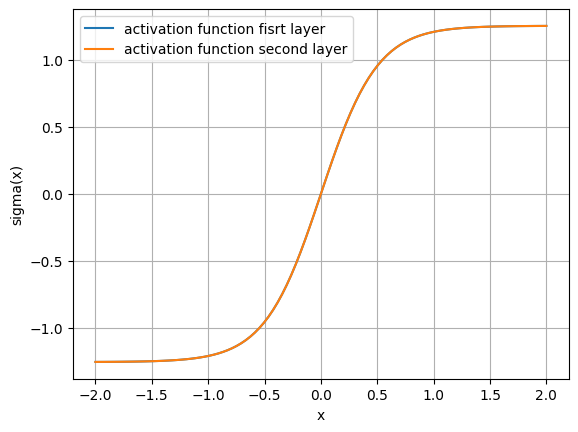

[ 0.00000000e+00  9.15241581e-01  0.00000000e+00 -7.70333160e-01
  0.00000000e+00  1.96127188e+00  0.00000000e+00 -8.38348577e+00
  0.00000000e+00  5.04972045e+01  0.00000000e+00 -3.93355039e+02
  0.00000000e+00  3.76468557e+03  0.00000000e+00 -4.27840791e+04
  0.00000000e+00  5.63449142e+05  0.00000000e+00 -8.44293231e+06
  0.00000000e+00  1.41906748e+08  0.00000000e+00 -2.64496885e+09]
[ 0.00000000e+00  9.15241581e-01  0.00000000e+00 -7.70333160e-01
  0.00000000e+00  1.96127188e+00  0.00000000e+00 -8.38348577e+00
  0.00000000e+00  5.04972045e+01  0.00000000e+00 -3.93355039e+02
  0.00000000e+00  3.76468557e+03  0.00000000e+00 -4.27840791e+04
  0.00000000e+00  5.63449142e+05  0.00000000e+00 -8.44293231e+06
  0.00000000e+00  1.41906748e+08  0.00000000e+00 -2.64496885e+09]
0.9999999999999999
0.9999999999999999


In [5]:
# Choose the activation function among the activations below
# The cell computes the first num_coeff Hermite coefficients and defines the function g()

activation_1 = 'Tanh unitary'
activation_2 = 'Tanh unitary'
num_coeff = 23

if (activation_1 == 'Linear'):

    def sigma_1(x):
        return x

elif (activation_1 == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_1(x):
        return np.tanh(2*x)/np.sqrt(var)   

elif (activation_1 == 'Tanh unitary no linear'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x) - 0.729477531486114827430355944671*x)**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_1(x):
        return (np.tanh(2*x) - 0.729477531486114827430355944671*x)/np.sqrt(var) 

if (activation_2 == 'Linear'):

    def sigma_2(x):
        return x

elif (activation_2 == 'Tanh unitary'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x))**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_2(x):
        return np.tanh(2*x)/np.sqrt(var)   

elif (activation_2 == 'Tanh unitary no linear'):
    
    var, error = scipy.integrate.quad(lambda x: (np.tanh(2*x) - 0.729477531486114827430355944671*x)**2 *np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)

    def sigma_2(x):
        return (np.tanh(2*x) - 0.729477531486114827430355944671*x)/np.sqrt(var)         
          
    
coefficients_1 = hermite_coefficients(lambda x: sigma_1(x), num_coeff, -10, 10)
coefficients_2 = hermite_coefficients(lambda x: sigma_2(x), num_coeff, -10, 10)

  # Create the approximation function using the computed coefficients
def g_1_func(x):
    g = 0
    for i in range(3,len(coefficients_1)):
      g += coefficients_1[i]**2 * x**i / math.factorial(i)
    return g

def g_1_prime(x):
    g = 0
    for i in range(3,len(coefficients_1)):
      g += coefficients_1[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

def g_2_func(x):
    g = 0
    for i in range(3,len(coefficients_2)):
      g += coefficients_2[i]**2 * x**i / math.factorial(i)
    return g

def g_2_prime(x):
    g = 0
    for i in range(3,len(coefficients_2)):
      g += coefficients_2[i]**2 * x**(i-1) / math.factorial(i-1)
    return g

# Plot the original function
x = np.linspace(-2, 2, 100)
plt.plot(x, sigma_1(x), label='activation function fisrt layer')
plt.plot(x, sigma_2(x), label='activation function second layer')

plt.xlabel('x')
plt.ylabel('sigma(x)')
plt.legend()
plt.grid(True)
plt.show()

print(coefficients_1)
print(coefficients_2)
var_activ_1, error_activ_1 = scipy.integrate.quad(lambda x: sigma_1(x)**2 * np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
var_activ_2, error_activ_2 = scipy.integrate.quad(lambda x: sigma_2(x)**2 * np.exp(-x**2/2)/(np.sqrt(2*np.pi)), -10, 10)
print(var_activ_1)
print(var_activ_2)

In [8]:
# Compute the MMSE, overlaps and free entropy of the specialization phase at different values of alpha
# Depending on the initialisation one obtaines different fixed points
mult_sigma = 5  
num_s2 = 100  # Number of states of s2
num_v = 100  # Number of states of v
mean_v = 0  # Mean of the Gaussian prior on v
std_v = 1  # Standard deviation of the Gaussian prior on v
mean_s2 = 0
std_s2 = np.sqrt(mean_v**2+std_v**2)
s2_gauss, P_s2_gauss = get_discrete_gaussian_on_grid(num_v,mean_s2,std_s2,mult_sigma)
v = [1]
P_v = [1]

s2_gauss = np.array(s2_gauss)
P_s2_gauss = np.array(P_s2_gauss)
v = np.array(v)
P_v = np.array(P_v)
q_W1_init_info = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_info = 0.99*np.ones([v.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_info = 0.99*np.ones(v.shape[0]) # initial guess for q_W21
q_W1_init_unfo1 = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo1 = 0*np.ones([v.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo1 = 0*np.ones(v.shape[0]) # initial guess for q_W21
q_W1_init_unfo2 = 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_unfo2 = 0*np.ones([v.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfo2 = 0.99*np.ones(v.shape[0]) # initial guess for q_W21
q_W1_init_unfoN = 0.99*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W1_init_unfoN[140:261] = 0.0
q_W2_init_unfoN = 0.0*np.ones([v.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_unfoN = 0.0*np.ones(v.shape[0]) # initial guess for q_W21
q_W1_init_univ= 0.0*np.ones(s2_gauss.shape[0]) # initial guess for q_W1
q_W2_init_univ = 0.0*np.ones([v.shape[0],s2_gauss.shape[0]]) # initial guess for q_W2
q_W21_init_univ = 0.0*np.ones(v.shape[0]) # initial guess for q_W21

Delta = 0.2
Gamma_1 = 0.5
Gamma_2 = 0.5

# Range of alpha
Alpha_min = 0.01
Alpha_max = 8.5

init = Alpha_min
end = Alpha_max
num = 51

MMSE_NSB_FSB_info = []
q_W_1_NSB_FSB_info = []
q_W_2_NSB_FSB_info = []
q_W_12_NSB_FSB_info = []
q_W_1_NSB_FSB_info_mean = []
q_W_2_NSB_FSB_info_mean = []
q_W_12_NSB_FSB_info_mean = []
free_entropy_NSB_FSB_info = []
MMSE_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1 = []
q_W_2_NSB_FSB_unfo1 = []
q_W_12_NSB_FSB_unfo1 = []
q_W_1_NSB_FSB_unfo1_mean = []
q_W_2_NSB_FSB_unfo1_mean = []
q_W_12_NSB_FSB_unfo1_mean = []
free_entropy_NSB_FSB_unfo1 = []
MMSE_NSB_FSB_unfo2 = []
q_W_1_NSB_FSB_unfo2 = []
q_W_2_NSB_FSB_unfo2 = []
q_W_12_NSB_FSB_unfo2 = [] 
q_W_1_NSB_FSB_unfo2_mean = []
q_W_2_NSB_FSB_unfo2_mean = []
q_W_12_NSB_FSB_unfo2_mean = []
free_entropy_NSB_FSB_unfo2 = []
MMSE_NSB_FSB_unfoN = []
q_W_1_NSB_FSB_unfoN = []
q_W_2_NSB_FSB_unfoN = []
q_W_12_NSB_FSB_unfoN = [] 
q_W_1_NSB_FSB_unfoN_mean = []
q_W_2_NSB_FSB_unfoN_mean = []
q_W_12_NSB_FSB_unfoN_mean = []
free_entropy_NSB_FSB_unfoN = []
q_W_1_NSB_FSB_univ = []
q_W_2_NSB_FSB_univ = []
q_W_12_NSB_FSB_univ = [] 
MMSE_NSB_FSB_univ = []
q_W_1_NSB_FSB_univ_mean = []
q_W_2_NSB_FSB_univ_mean = []
q_W_12_NSB_FSB_univ_mean = []
free_entropy_NSB_FSB_univ = []


for Alpha in np.linspace(init, end, num=num):
  print('----------------------------------------------------------------')
  print("alpha =",Alpha)
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_info,q_W2_init_info,q_W21_init_info,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_info.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_info.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_info.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_info.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_info_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_info_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v))
  q_W_12_NSB_FSB_info_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v))
  free_entropy_NSB_FSB_info.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_unfo1,q_W2_init_unfo1,q_W21_init_unfo1,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_unfo1.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo1.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo1.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo1_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo1_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v))
  q_W_12_NSB_FSB_unfo1_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v))
  free_entropy_NSB_FSB_unfo1.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))  
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_unfo2,q_W2_init_unfo2,q_W21_init_unfo2,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_unfo2.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfo2.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfo2.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfo2_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfo2_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v))
  q_W_12_NSB_FSB_unfo2_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v))
  free_entropy_NSB_FSB_unfo2.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_unfoN,q_W2_init_unfoN,q_W21_init_unfoN,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_unfoN.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_unfoN.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_unfoN.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_unfoN.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_unfoN_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_unfoN_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v))
  q_W_12_NSB_FSB_unfoN_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v))
  free_entropy_NSB_FSB_unfoN.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))
  print('----------------------------------------------------------------')
  MMSE_NSB_FSB_new,q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new=mmse_qW_NSB_FSB_fast(q_W1_init_univ,q_W2_init_univ,q_W21_init_univ,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False)
  MMSE_NSB_FSB_univ.append(MMSE_NSB_FSB_new)
  q_W_1_NSB_FSB_univ.append(q_W_1_NSB_FSB_new)
  q_W_2_NSB_FSB_univ.append(q_W_2_NSB_FSB_new)
  q_W_12_NSB_FSB_univ.append(q_W_12_NSB_FSB_new)
  q_W_1_NSB_FSB_univ_mean.append(EE_s(q_W_1_NSB_FSB_new,P_s2_gauss))
  q_W_2_NSB_FSB_univ_mean.append(EE_s(EE_FSB(q_W_2_NSB_FSB_new,1,P_s2_gauss),P_v))
  q_W_12_NSB_FSB_univ_mean.append(EE_s(q_W_12_NSB_FSB_new,P_v))
  free_entropy_NSB_FSB_univ.append(free_entropy_NSB_FSB(q_W_1_NSB_FSB_new,q_W_2_NSB_FSB_new,q_W_12_NSB_FSB_new,g_1_func,g_1_prime,g_2_func,g_2_prime,v,P_v,s2_gauss,P_s2_gauss,coefficients_1,coefficients_2,Alpha,Gamma_1,Gamma_2,Delta, quench=False, opt='gauss'))


----------------------------------------------------------------
alpha = 0.01
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.17980000000000002
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
alpha = 0.3496
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------------------------------------
----------------------------------

C:\Users\rudys\AppData\Local\Temp\ipykernel_40120\510835591.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=small, loc='lower left')


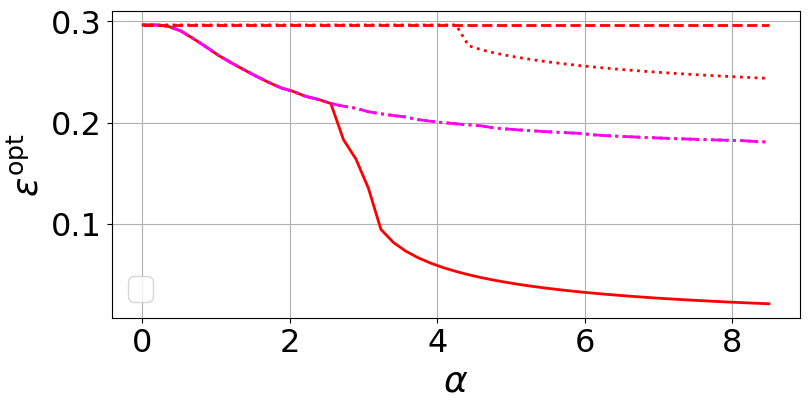

In [9]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

width, height = 7, 5
big, small = int(width*3.8), int(width*3.3)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_info, color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo1, ':', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfo2, ':', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_unfoN, '-.', color='magenta', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),MMSE_NSB_FSB_univ, '--', color='red', linewidth=2.0)

ax.set_xlabel(r'$\alpha$', fontsize=big)
ax.set_ylabel(r'$\varepsilon^{\rm opt}$', fontsize=big)
ax.grid(True)

plt.tight_layout()
plt.legend(fontsize=small, loc='lower left')
plt.tick_params(axis='both', which='major', labelsize=small)
plt.tick_params(axis='both', which='minor', labelsize=small)
plt.show()      

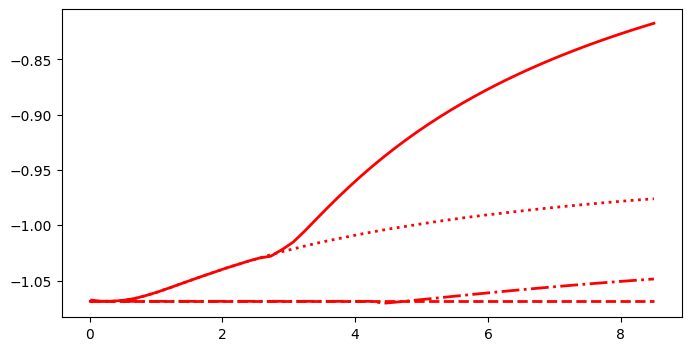

In [10]:
# plot the free entropy in the same way as the mmse
width, height = 7, 5
big, small = int(width*3.8), int(width*3.3)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_info, color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_unfo1, ':', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_unfo2, '-.', color='red', linewidth=2.0)
ax.plot(np.linspace(init, end, num=num),free_entropy_NSB_FSB_univ, '--', color='red', linewidth=2.0)


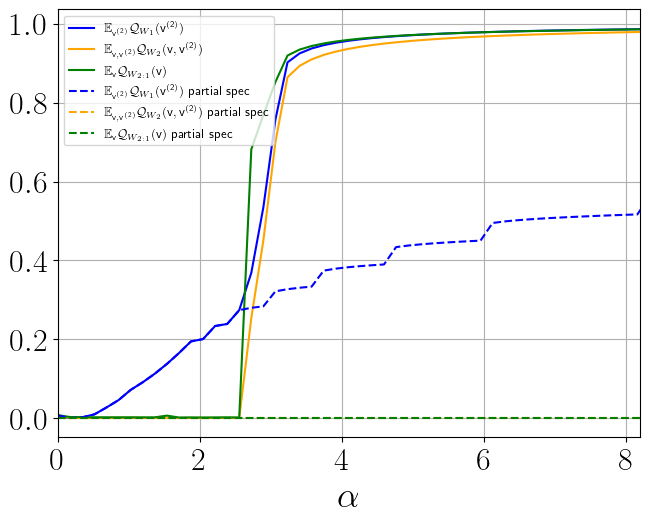

In [11]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsfonts}\usepackage{amssymb}'

smaller = int(width*1.3)

plt.plot(np.linspace(init, end, num=num),np.array(q_W_1_NSB_FSB_info_mean),label=r'$\mathbb{E}_{\mathsf{v^{(2)}}} \mathcal{Q}_{W_1}(\mathsf{v^{(2)}})$',color='blue')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_2_NSB_FSB_info_mean),label=r'$\mathbb{E}_{\mathsf{v},\mathsf{v^{(2)}}} \mathcal{Q}_{W_2}(\mathsf{v},\mathsf{v^{(2)}})$',color='orange')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_12_NSB_FSB_info_mean),label=r'$\mathbb{E}_{\mathsf{v}} \mathcal{Q}_{W_{2:1}}(\mathsf{v})$',color='green')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_1_NSB_FSB_unfo1_mean),'--',label=r'$\mathbb{E}_{\mathsf{v^{(2)}}} \mathcal{Q}_{W_1}(\mathsf{v^{(2)}})$ partial spec',color='blue')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_2_NSB_FSB_unfo1_mean),'--',label=r'$\mathbb{E}_{\mathsf{v},\mathsf{v^{(2)}}} \mathcal{Q}_{W_2}(\mathsf{v},\mathsf{v^{(2)}})$ partial spec',color='orange')
plt.plot(np.linspace(init, end, num=num),np.array(q_W_12_NSB_FSB_unfo1_mean),'--',label=r'$\mathbb{E}_{\mathsf{v}} \mathcal{Q}_{W_{2:1}}(\mathsf{v})$ partial spec',color='green')

plt.tight_layout()
plt.xlabel(r'$\alpha$', fontsize=big)
plt.legend(fontsize=smaller)
plt.tick_params(axis='both', which='major', labelsize=small)
plt.tick_params(axis='both', which='minor', labelsize=small)
plt.xlim(0, 8.2)
plt.grid(True)
plt.show()